---
title: "Light-off in a monolithic catalytic converter"
description: "An ignition front sweeping down a monolith channel, and the wrong-way temperature rise that appears when the same converter is suddenly cooled."
categories: [sec:I, struct:S4, struct:S7, tier:T0, data:tier6, phase:gas-solid]
date: 2026-07-30
---

# Light-off in a monolithic catalytic converter

**Catalog ID:** `I1.2` · **Structures:** `S4` (transient 1-D convection–reaction),
`S7` (two-phase gas/solid with interfacial transfer) · **Tier:** T0

A cold converter meets hot exhaust. For the first minute almost nothing is
converted — the gas is simply heating a large lump of ceramic. Then the wall
ignites somewhere near the outlet, and the hot spot walks *upstream* against the
flow until it sits at the inlet. Run the same model backwards — hot converter,
cold exhaust — and the wall temperature goes *up* by 241 °C, the paper's number,
before it comes down.

## Background

A monolith converter is a block of ceramic with a few thousand parallel square
channels, washcoated and impregnated with platinum. Every channel is a small
laminar tube reactor whose wall both catalyses the reaction and stores heat.
That storage is the whole story of the transient: the gas residence time is
about 9 ms, the wall thermal time constant is several seconds, so on any
timescale that matters the gas phase is quasi-steady and the wall is the only
thing with memory.

Oh and Cavendish wrote this model to answer a regulatory question. The US
Federal Test Procedure begins with a cold start, so most of a car's certified
emissions are produced in the first minute, before the converter lights off. The
model was used to ask which design parameters shorten that minute — cell
density, monolith length, noble-metal distribution — and, in the second half of
the paper, why converters occasionally *melt* during a sudden deceleration.

Two things make it a good pymrm problem rather than a correlation.

**It is genuinely two-phase.** Gas and solid have separate temperatures and
separate concentrations, coupled by film transfer. The solid temperature obeys a
parabolic PDE with axial conduction; the gas obeys first-order ODEs in $x$ with
no time derivative at all; the surface concentrations obey a pointwise algebraic
system. One time step therefore requires solving a differential–algebraic system
in twelve fields at once.

**The ignition front is a moving structure.** Anything reported about it — when
light-off happens, where the hot spot is — has to be shown to be a property of
the equations rather than of the grid. That is the reason for the refinement
study below.

## The published model

Five species are tracked, $i = 1\ldots 5$: CO, C$_3$H$_6$, CH$_4$, H$_2$, O$_2$.
Propylene stands in for fast-oxidising hydrocarbons and methane for slow ones.
Concentrations are **mole fractions** throughout.

**Gas phase** (their eqs 9–10), with the accumulation terms dropped because the
gas time constant is milliseconds against the solid's seconds:

$$
u\,\frac{\partial c_{g,i}}{\partial x} = -k_{m,i} S\,(c_{g,i} - c_{s,i}),
\qquad
u\rho_g C_{pg}\frac{\partial T_g}{\partial x} = h S\,(T_s - T_g).
$$

**Solid phase** (their eqs 11–12). The first is algebraic — what reacts at the
wall is what arrives at the wall:

$$
a(x)\,\tilde R_i(\bar c_s, T_s) = \frac{P_{\rm tot}}{R_g T_g}\,k_{m,i} S\,(c_{g,i}-c_{s,i}),
$$

$$
(1-\epsilon)\rho_s \frac{\partial (C_{ps} T_s)}{\partial t}
= \lambda_s (1-\epsilon)\frac{\partial^2 T_s}{\partial x^2}
+ hS\,(T_g - T_s) + a(x)\sum_{i=1}^{4}(-\Delta H)_i\,\tilde R_i(\bar c_s, T_s).
$$

Boundary and initial conditions (their eqs 13–16): $c_{g,i}=c_{g,i}^{\rm in}$ and
$T_g = T_g^{\rm in}$ at $x=0$; $\partial T_s/\partial x = 0$ at **both** ends, so
the solid exchanges no heat with the surroundings; $T_s(x,0)=T_{s0}(x)$.

**Kinetics** (their eqs 1–8) are Voltz et al. (1973) with only the
pre-exponential factors recalibrated against General Motors' own recycle-reactor
data. Rates are per unit platinum area, mol/(cm² Pt·s):

$$
\tilde R_{\rm CO} = \frac{k_1 c_{\rm CO} c_{\rm O_2}}{G},\quad
\tilde R_{\rm C_3H_6} = \frac{k_2 c_{\rm C_3H_6} c_{\rm O_2}}{G},\quad
\tilde R_{\rm CH_4} = \frac{k_3 c_{\rm CH_4} c_{\rm O_2}}{G},\quad
\tilde R_{\rm H_2} = \frac{k_1 c_{\rm H_2} c_{\rm O_2}}{G},
$$

$$
G = T\,(1 + K_1 c_{\rm CO} + K_2 c_{\rm C_3H_6})^2
     (1 + K_3 c_{\rm CO}^2 c_{\rm C_3H_6}^2)(1 + K_4 c_{\rm NO}^{0.7}).
$$

The $G$ denominator is the reason light-off is *delayed* by more CO: the rate is
negative order in its own reactant over most of the warm-up. Note $G$ carries a
factor $T$, so $k_i$ has units of mol·K/(cm² s) — that factor is easy to lose.

### Two things the equations say that are easy to misread

**The heat capacity sits inside the time derivative.** Equation 12 is written as
$\partial(C_{ps}T_s)/\partial t$, not $C_{ps}\,\partial T_s/\partial t$, and the
paper's Nomenclature confirms it by defining
$\Psi(T_s)=(1-\epsilon)\rho_s[C_{ps} + T_s\,\mathrm{d}C_{ps}/\mathrm{d}T_s]$ for
its eq 19. Printed twice, so not a typo. With the tabulated
$C_{ps}=1.071 + 1.56\times10^{-4}T_s - 3.435\times10^{4}/T_s^{2}$ the two
readings differ by a factor of about 2 in the effective thermal inertia at
300 K, which is not a detail. The validation section shows the paper's own
Table III picking between them.

**$R_h$ is the hydraulic radius as the paper defines it**, $2\times$(area /
wetted perimeter), i.e. *half* the usual hydraulic diameter — which is why eqs
17–18 read $h = Nu_\infty \lambda_g/(2R_h)$ and $k_{m,i} = Sh_\infty D_i/(2R_h)$.
Reading $R_h$ as a radius in the ordinary sense would double both transfer
coefficients.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags_array
from scipy.sparse.linalg import spsolve
from pymrm import (generate_grid, construct_grad, construct_div,
                   construct_convflux_upwind, construct_coefficient_matrix,
                   compute_boundary_values, NumJac, newton, clip_approach)
from gallery_utils import load_data, load_meta, cite_data, report_agreement

PAGE = "I1.2-catalytic-converter-lightoff"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

## Parameters and assumptions

**Assumptions, as stated by the authors:** one dimension, so gas temperature,
concentration and velocity are cross-sectional averages; no transverse
temperature gradient in the solid; no axial diffusion of heat or mass in the
gas; reaction only on the external surface of the catalytic wall, so no
washcoat diffusion; quasi-steady gas phase; axial conduction retained in the
solid, which the paper shows matters; ideal gas.

**Four quantities the model needs are not printed in the paper.** None of them
is invented here; each comes from a source the paper itself names, and each is
checked below.

| Quantity | Where it comes from | Check on the page |
|---|---|---|
| $S$, geometric area per unit volume | follows from the channel geometry, $S = 2\epsilon/R_h$ | reproduces Table II exactly |
| $D_i$ | Slattery–Bird, the formula the paper cites (Bird et al. 1960, p. 505) | the paper's own statement that $Le_{\rm H_2}\approx4$ |
| $Nu_\infty$, $Sh_\infty$ | Shah & London for a square duct; the paper says "constant wall heat flux" but prints no number | Table III selects between the three tabulated square-duct values |
| $(-\Delta H)_i$ | standard formation enthalpies, water as vapour | the adiabatic temperature rise closes the steady-state energy balance |

The mean molecular weight of the exhaust is also unstated; it is taken as
28.97 g/mol (air), and it enters only through the gas velocity.

In [3]:
par = load_data("oh-cavendish-1982-parameters.csv", page=PAGE)
geo = load_data("oh-cavendish-1982-cell-density.csv", page=PAGE)
res = load_data("oh-cavendish-1982-results.csv", page=PAGE)
res_meta = load_meta("oh-cavendish-1982-results.csv", page=PAGE)

# Resolve the table to a plain dict once. P() ends up inside the Newton
# residual, so it must not be a pandas lookup - that alone made the notebook
# an order of magnitude slower than the linear algebra it wraps.
_PAR = {(r.symbol, r.case): float(r.value) for r in par.itertuples()}

def P(sym, case="both"):
    """Look up one Table I value, for a given case."""
    return _PAR.get((sym, case), _PAR.get((sym, "both")))

print(cite_data(res_meta))
print()
print(par[par.case == "both"].head(13).to_string(index=False))

Oh, S. H.; Cavendish, J. C. (1982) — Industrial & Engineering Chemistry Product Research and Development 21(1) 29-37 — doi:10.1021/i300005a006 — table

  symbol         value       unit                                                    description case  source
   P_tot    101.300000        kPa                                                 total pressure both Table I
     W_g     40.000000        g/s                                  mass flow rate of exhaust gas both Table I
       A     60.000000        cm2                                   frontal area of the monolith both Table I
       L     10.000000         cm                                             length of monolith both Table I
     R_h      0.060620         cm hydraulic radius 2*(area/wetted perimeter) of a square channel both Table I
     eps      0.683600          -                                  void fraction of the monolith both Table I
   rho_s      2.500000      g/cm3                                             

## The data

Three datasets, all Tier 2 transcription from printed tables — no figure was
digitised for this page and none is needed.

- **parameters** — Table I plus the rate constants of eqs 5–6.
- **cell-density** — Table II, used as an integrity check rather than as input.
- **results** — Table III and the numerical values in the running text. **These
  are not measurements.** They are the authors' own computed results, from a
  Galerkin discretisation on 81 grid points integrated with GEAR. The paper
  contains no experimental data of any kind, so this page is provenance tier 6,
  validated against a published reference solution in the same sense as
  [`B1.1`](../B1.1-thiele-weisz-hicks/) and
  [`D2.2`](../D2.2-van-welsenaere-froment-runaway/).

The asymmetry between the two cases matters and is stated here rather than
buried: **case 2 (the step decrease) has six published numbers to check against;
case 1 (light-off) has none.** The paper reports light-off entirely as figures.
So the light-off time below is a prediction of this reimplementation, and the
only thing that can be shown about it is that it is converged and that the
qualitative sequence the paper describes in words comes out.

### Table II is a free check on the transcription

For square channels of pitch $p = 1/\sqrt{n_{\rm cell}}$ and wall thickness
$w = 0.0254$ cm, the open side is $s = p - w$, so $R_h = s/2$ and
$\epsilon = (s/p)^2$. Two stated inputs, six printed numbers. If the reading of
$R_h$ as *half* the hydraulic diameter were wrong, this would miss by a factor
of two.

In [4]:
w_wall = 0.0254   # cm, stated in the text under Table II
p_pitch = 1.0 / np.sqrt(geo.cell_density_per_cm2.to_numpy())
s_open = p_pitch - w_wall
geo_chk = geo.assign(R_h_calc=s_open / 2, eps_calc=(s_open / p_pitch) ** 2)
geo_chk["R_h_err_pct"] = 100 * (geo_chk.R_h_calc - geo_chk.R_h_cm) / geo_chk.R_h_cm
geo_chk["eps_err_pct"] = 100 * (geo_chk.eps_calc - geo_chk.void_fraction) / geo_chk.void_fraction
geo_max_err = float(np.abs(geo_chk[["R_h_err_pct", "eps_err_pct"]].to_numpy()).max())
print(geo_chk.round(5).to_string(index=False))
print(f"\nworst deviation over all six printed numbers: {geo_max_err:.3f} %")

 cell_density_per_cm2  R_h_cm  void_fraction     note  R_h_calc  eps_calc  R_h_err_pct  eps_err_pct
                 31.0 0.07710         0.7371      NaN   0.07710   0.73716      0.00344      0.00780
                 46.5 0.06062         0.6836 standard   0.06062   0.68359      0.00587     -0.00144
                 93.0 0.03915         0.5696      NaN   0.03915   0.57010     -0.00617      0.08821

worst deviation over all six printed numbers: 0.088 %


## PyMRM implementation

Twelve fields per axial cell, laid out `(n_x, 12)` with the spatial axis first:

| index | field | equation |
|---|---|---|
| 0 | $T_s$ | eq 12, parabolic |
| 1 | $T_g$ | eq 10, first order in $x$ |
| 2–6 | $c_{g,i}$ | eq 9, first order in $x$ |
| 7–11 | $c_{s,i}$ | eq 11, algebraic |

**The convection is written as a flux divergence with a constant carrier, which
is exact here.** The superficial velocity varies by a factor of three along the
channel because the gas heats up, so `u * dc/dx` and `d(u c)/dx` are not the
same operator. But $u\rho_g = W_g/A$ and $u\,C_{\rm tot} = W_g/(A M)$ are both
*constants*: mass flux and molar flux do not change even though $u$ does. Writing
the two gas equations as $\mathrm{d}(G_{\rm mass}C_{pg}T_g)/\mathrm{d}x$ and
$\mathrm{d}(G_{\rm mol}\,c_{g,i})/\mathrm{d}x$ therefore reproduces the paper's
eqs 9–10 exactly while keeping the convection operator constant, so it is
assembled once.

Three operator assemblies, all constant, all outside the time loop:

- `construct_grad` + `construct_div` with a coefficient matrix that is
  $\lambda_s(1-\epsilon)$ on field 0 and zero on all the others — that is how a
  single field gets a diffusion term in a monolithic system.
- `construct_convflux_upwind` with a per-field velocity vector that is zero on
  the solid fields, so the divergence operator returns zero for them.
- `NumJac(shape)` with the default stencil, which couples only the last axis.
  That is exactly right: every remaining term — reaction, film transfer,
  accumulation — is pointwise in $x$.

**Two numerical points that are not decoration.** The twelve fields span eleven
orders of magnitude (750 K against $5\times10^{-5}$ mole fraction of methane) and
the residuals span eight, so the Newton system is scaled on both sides by
constant diagonal matrices; without that the sparse solve reports an exactly
singular Jacobian on the first step. And the Newton direction is limited to
100 K and half an inlet mole fraction per iteration, through the documented
`solver=` hook, because an undamped step from the initial guess overshoots into
negative temperature.

In [5]:
R_GAS = 8.314          # J/(mol K)
M_GAS = 28.97          # g/mol, exhaust taken as air-like (not in the paper)
SPECIES = ["CO", "C3H6", "CH4", "H2", "O2"]

# Heats of combustion, J/mol, from standard formation enthalpies with water as
# vapour. NOT printed in the paper; standard thermochemistry.
DH = np.array([282.98e3, 1926.42e3, 802.29e3, 241.826e3])

# Critical constants for the Slattery-Bird formula (Bird et al. 1960, p. 505).
TC = {"CO": 133.0, "C3H6": 365.0, "CH4": 190.7, "H2": 33.3, "O2": 154.4, "N2": 126.2}
PC = {"CO": 34.5, "C3H6": 45.6, "CH4": 45.8, "H2": 12.8, "O2": 49.7, "N2": 33.5}
MW = {"CO": 28.01, "C3H6": 42.08, "CH4": 16.04, "H2": 2.016, "O2": 32.00, "N2": 28.013}


SB_A, SB_B = 2.745e-4, 1.823          # non-polar pair, Bird et al. eq. 16.3-1

def sb_coefficient(sp, b_sp="N2"):
    """Everything in the Slattery-Bird formula that does not depend on T."""
    tc = TC[sp] * TC[b_sp]
    return (SB_A * tc ** (-SB_B / 2) * (PC[sp] * PC[b_sp]) ** (1 / 3)
            * tc ** (5 / 12) * np.sqrt(1 / MW[sp] + 1 / MW[b_sp]))

SB_COEF = np.array([sb_coefficient(s) for s in SPECIES])

def d_slattery_bird(sp, T, p_atm=1.0):
    """Binary diffusivity of `sp` in N2, cm2/s (Bird et al. 1960, eq. 16.3-1)."""
    return sb_coefficient(sp) * T ** SB_B / p_atm

# Table I / text constants pulled out as plain floats: these are read inside
# the Newton residual and must not stay as DataFrame lookups.
LAMG_A, LAMG_N = P("lambda_g_A"), P("lambda_g_n")
CPS = (P("C_ps_c0"), P("C_ps_c1"), P("C_ps_c2"))
KIN = tuple((P(f"k{i}_A"), P(f"k{i}_E_over_R")) for i in (1, 2, 3))
ADS = tuple((P(f"K{i}_A"), P(f"K{i}_dH_over_R")) for i in (1, 2, 3, 4))


def lam_gas(T):
    """Thermal conductivity of the mixture, approximated by N2 (paper, p. 31)."""
    return LAMG_A * T ** LAMG_N


def cp_solid(T):
    """Table I: C_ps(T), J/(g K)."""
    return CPS[0] + CPS[1] * T + CPS[2] / T ** 2

In [6]:
class Monolith:
    """Oh & Cavendish (1982), eqs 9-12, monolithic implicit in twelve fields."""

    def __init__(self, y_in, y_no, T_g_in, T_s0, n_x=80, nu_nusselt=3.608,
                 sh=3.608, lam_s=None, a_pt=None, eps=None, r_h=None,
                 enthalpy_form=True):
        self.n_x, self.n_c = n_x, 12
        self.nu_nusselt, self.sh = nu_nusselt, sh
        self.lam_s = P("lambda_s") if lam_s is None else lam_s
        self.a_pt = P("a") if a_pt is None else a_pt
        self.eps = P("eps") if eps is None else eps
        self.r_h = P("R_h") if r_h is None else r_h
        self.length, self.p_tot = P("L"), P("P_tot") * 1e3      # cm, Pa
        self.rho_s, self.cp_g = P("rho_s"), P("C_pg")
        self.T_g_in, self.T_s0, self.y_no = T_g_in, T_s0, y_no
        self.y_in = np.asarray(y_in, float)
        self.enthalpy_form = enthalpy_form
        self.s_geo = 2.0 * self.eps / self.r_h        # cm2/cm3, from the geometry
        self.g_mass = P("W_g") / P("A")               # g/(cm2 s), constant
        self.g_mol = self.g_mass / M_GAS              # mol/(cm2 s), constant
        self.dt = 1.0
        self._build_grid()
        self._build_operators()
        self._init_state()

    # ---------------------------------------------------------------- grid
    def _build_grid(self):
        self.x_f, self.x_c = generate_grid(self.n_x, [0.0, self.length],
                                           generate_x_c=True)
        self.dx = self.length / self.n_x

    # ----------------------------------------------------------- operators
    def _build_operators(self):
        shape = (self.n_x, self.n_c)
        shape_f = (self.n_x + 1, self.n_c)

        # eq 15, adiabatic at both ends, with the OUTWARD normal:
        #   left  dTs/dn = -dTs/dx = 0 ;  right  dTs/dn = +dTs/dx = 0
        bc_diff = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        grad_mat, grad_bc = construct_grad(shape, self.x_f, self.x_c, bc_diff, axis=0)
        lam = np.zeros(self.n_c)
        lam[0] = self.lam_s * (1.0 - self.eps)     # conduction on T_s only
        lam_mat = construct_coefficient_matrix(lam, shape=shape_f, axis=-1)
        div_mat = construct_div(shape, self.x_f, nu=0, axis=0)   # nu=0: Cartesian slab

        # constant carriers: mass flux for T_g, molar flux for the mole fractions
        v = np.zeros(self.n_c)
        v[1] = self.g_mass * self.cp_g
        v[2:7] = self.g_mol
        d_in = np.zeros(self.n_c)
        d_in[1] = self.T_g_in                      # eq 14
        d_in[2:7] = self.y_in                      # eq 13
        bc_conv = ({"a": np.zeros(self.n_c), "b": np.ones(self.n_c), "d": d_in},
                   {"a": np.ones(self.n_c), "b": np.zeros(self.n_c),
                    "d": np.zeros(self.n_c)})      # outlet: zero gradient
        conv_mat, conv_bc = construct_convflux_upwind(shape, self.x_f, self.x_c,
                                                      bc_conv, v=v, axis=0)
        self.bc_conv = bc_conv

        self.jac_lin = (-div_mat @ (lam_mat @ grad_mat) + div_mat @ conv_mat).tocsc()
        self.g_lin = np.asarray(
            (-div_mat @ (lam_mat @ grad_bc) + div_mat @ conv_bc).todense()).reshape(-1, 1)
        self.numjac = NumJac(shape)                # last-axis coupling: pointwise
        self._build_scaling(shape)

    def _build_scaling(self, shape):
        """Constant two-sided diagonal scaling; without it the solve is singular."""
        t_ref = 1000.0
        y_ref = np.maximum(self.y_in, 1e-5)
        self.col_scale = np.concatenate(([t_ref, t_ref], y_ref, y_ref))
        h_ref = self.nu_nusselt * lam_gas(600.0) / (2 * self.r_h) * self.s_geo
        km_ref = (self.sh * SB_COEF * 600.0 ** SB_B
                  / (2 * self.r_h) * self.s_geo * self.p_tot / (R_GAS * 600.0) / 1e6)
        self.row_scale = np.concatenate(([1 / (h_ref * t_ref)] * 2,
                                         1 / (km_ref * y_ref), 1 / (km_ref * y_ref)))
        # every species is consumed only, so 0 <= y <= y_in everywhere
        self._lb = np.concatenate(([250 / t_ref] * 2, np.zeros(10)))
        self._ub = np.concatenate(([3000 / t_ref] * 2,
                                   self.y_in / y_ref, self.y_in / y_ref))
        cs = np.broadcast_to(self.col_scale, shape).reshape(-1)
        rs = np.broadcast_to(self.row_scale, shape).reshape(-1)
        self._Dc, self._Dr = diags_array(cs, format="csc"), diags_array(rs, format="csc")
        self._rs = rs.reshape(-1, 1)

    def outlet(self, u=None):
        """Gas state on the OUTLET FACE, as the convection operator sees it.

        Not the same as the last cell centre: with the zero-gradient outlet the
        face value is extrapolated, and the difference (3e-4 here) is exactly
        what stops a species balance written on cell values from closing.
        """
        u = self.u if u is None else u
        vals, _ = compute_boundary_values(u, self.x_f, self.x_c,
                                          bc=self.bc_conv[1], axis=0, bound_id=1)
        return np.asarray(vals).ravel()

    def _init_state(self):
        u = np.zeros((self.n_x, self.n_c))
        u[:, 0] = self.T_s0
        u[:, 1] = self.T_g_in
        u[:, 2:7] = self.y_in
        u[:, 7:12] = self.y_in
        self.u = u

    # ------------------------------------------------------------- physics
    def rates(self, y_s, T_s):
        """Specific rates, mol/(cm2 Pt s); eqs 1-8. Order: CO C3H6 CH4 H2 O2."""
        k1, k2, k3 = (a * np.exp(-e / T_s) for a, e in KIN)
        K1, K2, K3, K4 = (a * np.exp(-e / T_s) for a, e in ADS)
        co, hc, ch4, h2, o2 = (y_s[..., i] for i in range(5))
        G = (T_s * (1 + K1 * co + K2 * hc) ** 2
             * (1 + K3 * co ** 2 * hc ** 2) * (1 + K4 * self.y_no ** 0.7))
        r_co, r_hc = k1 * co * o2 / G, k2 * hc * o2 / G
        r_ch4, r_h2 = k3 * ch4 * o2 / G, k1 * h2 * o2 / G   # eq 7: H2 uses k1
        r_o2 = 0.5 * r_co + 4.5 * r_hc + 2.0 * r_ch4 + 0.5 * r_h2   # eq 8
        return np.stack([r_co, r_hc, r_ch4, r_h2, r_o2], axis=-1)

    def transport(self, Tg):
        h = self.nu_nusselt * lam_gas(Tg) / (2.0 * self.r_h)            # eq 17
        d_i = SB_COEF * (Tg ** SB_B)[..., None]                         # Slattery-Bird
        km = self.sh * d_i / (2.0 * self.r_h)                           # eq 18
        c_tot = self.p_tot / (R_GAS * Tg) / 1e6                         # mol/cm3
        return h, km, c_tot

    def enthalpy(self, T):
        """Solid enthalpy per gram. Eq 12 as printed puts C_ps inside d/dt."""
        if self.enthalpy_form:
            return cp_solid(T) * T
        # alternative reading: C_ps is the true heat capacity, rho*c_p*dT/dt
        return CPS[0] * T + 0.5 * CPS[1] * T ** 2 - CPS[2] / T

    def source(self, u):
        """Every pointwise term: accumulation, film transfer, reaction."""
        Ts, Tg = u[..., 0], u[..., 1]
        y_g, y_s = u[..., 2:7], u[..., 7:12]
        h, km, c_tot = self.transport(Tg)
        rr = self.rates(y_s, Ts)
        exch = km * self.s_geo * c_tot[..., None] * (y_g - y_s)   # mol/(cm3 s)
        q = self.a_pt * (DH * rr[..., :4]).sum(axis=-1)           # J/(cm3 s)
        acc = (1 - self.eps) * self.rho_s * self.enthalpy(Ts)
        f = np.zeros_like(u)
        f[..., 0] = -acc / self.dt + h * self.s_geo * (Tg - Ts) + q
        f[..., 1] = h * self.s_geo * (Ts - Tg)
        f[..., 2:7] = -exch
        f[..., 7:12] = -self.a_pt * rr + exch
        return f

    # -------------------------------------------------------------- solver
    def residual(self, w, g_old):
        u = w.reshape(self.u.shape) * self.col_scale
        f, jac_f = self.numjac(self.source, u)
        g = self.jac_lin @ u.reshape(-1, 1) + self.g_lin - f.reshape(-1, 1) - g_old
        return self._rs * g, (self._Dr @ (self.jac_lin - jac_f) @ self._Dc).tocsc()

    def _limited_direction(self, jac, g, **kw):
        """newton(solver=...) hook: cap one Newton step at 100 K / 0.5 y_in."""
        dx = spsolve(jac, g)
        d = dx.reshape(self.u.shape)
        fac = 1.0
        m_t, m_y = np.abs(d[:, :2]).max(), np.abs(d[:, 2:]).max()
        if m_t > 0.1:
            fac = min(fac, 0.1 / m_t)
        if m_y > 0.5:
            fac = min(fac, 0.5 / m_y)
        return fac * dx

    def step(self, dt, tol=1e-9, maxfev=40):
        self.dt = dt
        g_old = np.zeros(self.u.shape)
        g_old[..., 0] = (1 - self.eps) * self.rho_s * self.enthalpy(self.u[..., 0]) / dt
        g_old = g_old.reshape(-1, 1)
        r = newton(lambda w: self.residual(w, g_old), self.u / self.col_scale,
                   tol=tol, maxfev=maxfev, solver=self._limited_direction,
                   callback=lambda x, g: clip_approach(
                       x, None, lower_bounds=self._lb, upper_bounds=self._ub))
        self.u = r.x.reshape(self.u.shape) * self.col_scale
        return r

    def run(self, t_end, dt, record=None):
        """March to t_end. Returns times and whatever `record` collects."""
        t, out, ts = 0.0, [], [0.0]
        if record is not None:
            out.append(record(self))
        n_fail = 0
        for k in range(int(round(t_end / dt))):
            r = self.step(dt, maxfev=200 if k == 0 else 40)
            n_fail += not r.success
            t += dt
            ts.append(t)
            if record is not None:
                out.append(record(self))
        self.n_fail = n_fail
        return np.array(ts), out

### Filling the four gaps

$S$ comes from the geometry. $D_i$ comes from the formula the paper names.
$Nu_\infty$ and $Sh_\infty$ are the one real ambiguity: the paper says only
"analytical solutions for fully developed laminar flow with constant wall heat
flux (Shah and London, 1971)", and for a square duct that report gives three
different limiting Nusselt numbers depending on what "constant heat flux" means
— 3.608 for constant axial flux with a peripherally uniform wall temperature
(H1), 3.091 for constant flux peripherally too (H2), 2.976 for a constant wall
temperature (T). A ceramic wall conducts well around the perimeter, so H1 is the
physically indicated one; Table III is used below to confirm that, and the same
value is used for $Sh_\infty$ by the heat–mass transfer analogy the paper
invokes.

The Lewis number is the free check. The paper says H$_2$ has
$Le = D\rho_g C_{pg}/\lambda_g \approx 4$, which tests the Slattery–Bird
implementation, the $\lambda_g$ correlation and the mean molecular weight all at
once — and none of the three was chosen to make it come out.

In [7]:
T_chk = 600.0
rho_g_chk = P("P_tot") * 1e3 * M_GAS / (R_GAS * T_chk) / 1e6      # g/cm3
le = {s: d_slattery_bird(s, T_chk) * rho_g_chk * P("C_pg") / lam_gas(T_chk)
      for s in SPECIES}
le_h2 = le["H2"]
le_paper = float(res[res.quantity == "Lewis_number_H2"].value.iloc[0])
print(f"Lewis numbers at {T_chk:.0f} K: " +
      ", ".join(f"{s} {v:.2f}" for s, v in le.items()))
print(f"\nH2: {le_h2:.2f}  vs the paper's stated ~{le_paper:.0f}"
      f"   ({100*(le_h2-le_paper)/le_paper:+.1f} %)")

s_geo = 2 * P("eps") / P("R_h")
print(f"\nS = 2*eps/R_h = {s_geo:.3f} cm2/cm3 (not printed in the paper)")
print(f"gas residence time at 600 K = "
      f"{P('L') / (P('W_g')/P('A')/rho_g_chk)*1e3:.1f} ms")

Lewis numbers at 600 K: CO 1.00, C3H6 0.61, CH4 1.08, H2 3.89, O2 1.01

H2: 3.89  vs the paper's stated ~4   (-2.8 %)

S = 2*eps/R_h = 22.554 cm2/cm3 (not printed in the paper)
gas residence time at 600 K = 8.8 ms


## Results

### Case 1 — a step increase in feed temperature: light-off

Cold monolith at 300 K, hot exhaust at 600 K switched on at $t=0$. The reference
run uses 80 cells and $\Delta t = 0.1$ s; both are shown to be converged in the
validation section.

In [8]:
y1 = np.array([P("y_CO_in", "case 1"), P("y_C3H6_in", "case 1"),
               P("y_CH4_in", "case 1"), P("y_H2_in", "case 1"),
               P("y_O2_in", "case 1")])
y2 = np.array([P("y_CO_in", "case 2"), P("y_C3H6_in", "case 2"),
               P("y_CH4_in", "case 2"), P("y_H2_in", "case 2"),
               P("y_O2_in", "case 2")])

def snapshot(m):
    """One row of diagnostics per stored time level."""
    rr = m.rates(m.u[:, 7:12], m.u[:, 0])
    out = m.outlet()
    return dict(
        Ts=m.u[:, 0].copy(), Tg=m.u[:, 1].copy(),
        yg=m.u[:, 2:7].copy(),
        y_out=out[2:7].copy(),
        X=1.0 - out[2:7] / m.y_in,                         # outlet conversion
        q_rxn=float((m.a_pt * (DH * rr[:, :4]).sum(axis=-1)).sum() * m.dx),
        h_solid=float(((1 - m.eps) * m.rho_s * m.enthalpy(m.u[:, 0])).sum() * m.dx),
        Tg_out=float(out[1]),
        rate_int=(m.a_pt * rr).sum(axis=0) * m.dx,         # mol/(cm2 s)
    )

def light_off_time(ts, X, level=0.5, species=0):
    """First crossing of `level` conversion, linearly interpolated. Deterministic."""
    x = np.array([s["X"][species] for s in X])
    idx = np.flatnonzero(x >= level)
    if idx.size == 0 or idx[0] == 0:
        return np.nan
    i = idx[0]
    return float(np.interp(level, [x[i-1], x[i]], [ts[i-1], ts[i]]))

m1 = Monolith(y_in=y1, y_no=P("y_NO_in", "case 1"), T_g_in=P("T_g_in", "case 1"),
              T_s0=P("T_s0", "case 1"), n_x=80)
ts1, snap1 = m1.run(300.0, 0.1, record=snapshot)
print(f"case 1 reference run: {m1.n_fail} failed Newton solves")
t_lo = {nm: light_off_time(ts1, snap1, species=i)
        for i, nm in enumerate(SPECIES[:4])}
for nm, v in t_lo.items():
    print(f"  50 % conversion of {nm:<5s}: "
          + (f"{v:6.2f} s" if np.isfinite(v) else "never"))

case 1 reference run: 0 failed Newton solves
  50 % conversion of CO   :  47.12 s
  50 % conversion of C3H6 :  47.62 s
  50 % conversion of CH4  : never
  50 % conversion of H2   :  46.62 s


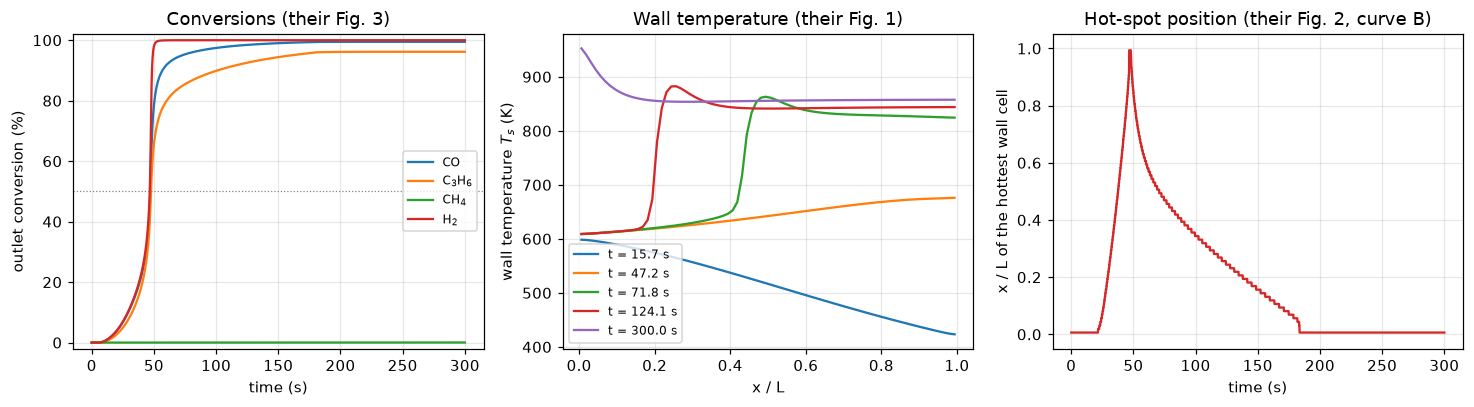

In [9]:
X1 = np.array([s["X"] for s in snap1])
peak_pos = np.array([m1.x_c[s["Ts"].argmax()] / m1.length for s in snap1])
peak_T = np.array([s["Ts"].max() for s in snap1])
paper_times = [15.7, 47.2, 71.8, 124.1, 300.0]

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))
for i, nm in enumerate(["CO", "C$_3$H$_6$", "CH$_4$", "H$_2$"]):
    ax[0].plot(ts1, 100 * X1[:, i], label=nm)
ax[0].axhline(50, color="0.5", lw=0.8, ls=":")
ax[0].set(xlabel="time (s)", ylabel="outlet conversion (%)",
          title="Conversions (their Fig. 3)", ylim=(-2, 102))
ax[0].legend(fontsize=8)

for tt in paper_times:
    j = np.argmin(abs(ts1 - tt))
    ax[1].plot(m1.x_c / m1.length, snap1[j]["Ts"], label=f"t = {ts1[j]:.1f} s")
ax[1].set(xlabel="x / L", ylabel="wall temperature $T_s$ (K)",
          title="Wall temperature (their Fig. 1)")
ax[1].legend(fontsize=8)

ax[2].plot(ts1, peak_pos, color="C3")
ax[2].set(xlabel="time (s)", ylabel="x / L of the hottest wall cell",
          title="Hot-spot position (their Fig. 2, curve B)", ylim=(-0.05, 1.05))
fig.tight_layout(); plt.show()

The three panels are the paper's Figures 3, 1 and 2 in that
order, at the five times its Figure 1 is drawn at.

What the paper says in words, and what comes out:

- *"their lightoff times (say, the time required for 50 % conversion) are similar
  except for CH$_4$"* — CO, C$_3$H$_6$ and H$_2$ light off within about a second
  of each other; methane never reaches 1 % in five minutes.
- *"At early times, the hot exhaust heats up the upstream portion of the monolith
  ($t = 15.7$ s). As time elapses, however, the downstream section becomes hotter
  ($t = 47.2$ s) … this temperature peak moves rather slowly toward the inlet
  ($t = 71.8$, 124.1 and 300 s)."* The hot-spot trace is exactly that: pinned at
  the inlet while the front is convective, thrown to the outlet at ignition, then
  walking back upstream over the following four minutes.
- *"H$_2$ in the exhaust leads to a solid temperature exceeding the adiabatic
  reaction temperature even at steady-state conditions … compare the wall
  temperature at $x = 0$ and $x = 1$ when $t = 300$ s."* Checked numerically
  below.

Note what the hot-spot panel costs to draw: the paper's Figure 2 required
re-running the whole transient, and its own caption reports only three curves.

### Case 2 — a step decrease in feed temperature: the wrong way

Now the converter starts hot and uniform at 750 K and is hit with cold exhaust
at 300 K carrying much more hydrocarbon. Cooling the front of the monolith
*stops* the reaction there, so unconverted fuel is delivered to a downstream
section that is still hot. The wall temperature goes up.

This is where the paper's six published numbers are, so this run uses the finer
grid.

In [10]:
def case2(lam_s=None, n_x=160, dt=0.05, t_end=14.0, nu=3.608,
          enthalpy_form=True):
    """Peak wall temperature and its location over the whole case-2 transient."""
    m = Monolith(y_in=y2, y_no=P("y_NO_in", "case 2"), T_g_in=P("T_g_in", "case 2"),
                 T_s0=P("T_s0", "case 2"), n_x=n_x, lam_s=lam_s,
                 nu_nusselt=nu, sh=nu, enthalpy_form=enthalpy_form)
    best = (0.0, 0.0, 0.0)
    t = 0.0
    profiles = []
    for k in range(int(round(t_end / dt))):
        m.step(dt, maxfev=200 if k == 0 else 40)
        t += dt
        j = int(m.u[:, 0].argmax())
        if m.u[j, 0] > best[0]:
            best = (float(m.u[j, 0]), float(m.x_c[j] / m.length), t)
        profiles.append((t, m.u[:, 0].copy(), m.u[:, 2].copy()))
    return best, m, profiles

# Table III rows, keyed by the conductivity parsed out of the condition string
tab3_ref = (res[res.condition.str.startswith("lambda_s")]
            .assign(lam=lambda d: d.condition.str.split()
                    .str[2].astype(float))
            .pivot(index="lam", columns="quantity", values="value")
            .sort_index())
lam_vals = list(tab3_ref.index)
c2 = {lam: case2(lam_s=lam) for lam in lam_vals}

rows = []
for lam in lam_vals:
    (Tmax, xmax, tmax), _, _ = c2[lam]
    ref_T = float(tab3_ref.loc[lam, "T_s_max"])
    ref_x = float(tab3_ref.loc[lam, "x_max_over_L"])
    rows.append(dict(lambda_s=lam, T_model=Tmax, T_paper=ref_T,
                     dT_pct=100 * (Tmax - ref_T) / ref_T,
                     x_model=xmax, x_paper=ref_x,
                     dx_cells=(xmax - ref_x) * 80, t_peak=tmax))
tab3 = pd.DataFrame(rows)
print(tab3.round(4).to_string(index=False))

 lambda_s  T_model  T_paper  dT_pct  x_model  x_paper  dx_cells  t_peak
   0.0017 990.4408    996.0 -0.5582   0.6656   0.6625      0.25    9.60
   0.0168 986.0571    991.0 -0.4988   0.6719   0.6750     -0.25    9.75
   0.1675 966.8707    975.0 -0.8338   0.7469   0.7625     -1.25   10.25


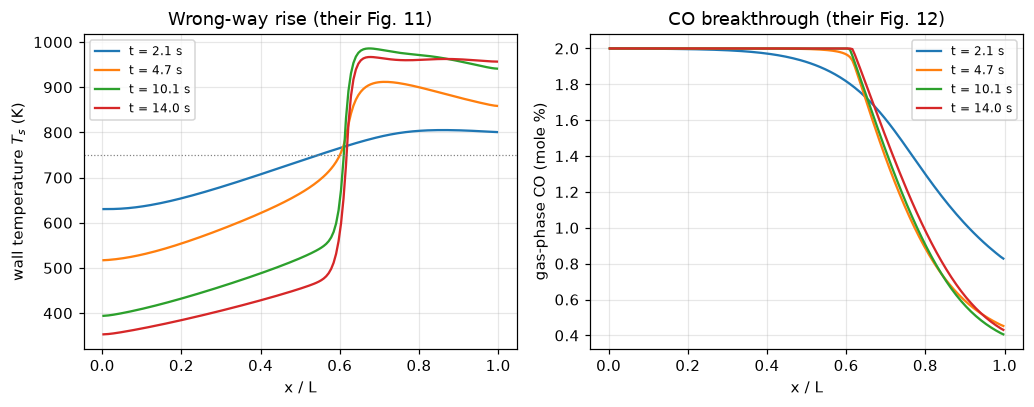

transient temperature rise: 236 degC   (paper: 241 degC)
time of the peak          : 9.75 s (paper: 10.1 s)


In [11]:
(_, m2, prof2) = c2[1.675e-2]
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
for tt in [2.1, 4.7, 10.1, 14.0]:
    j = int(np.argmin([abs(p[0] - tt) for p in prof2]))
    ax[0].plot(m2.x_c / m2.length, prof2[j][1], label=f"t = {prof2[j][0]:.1f} s")
    ax[1].plot(m2.x_c / m2.length, 1e2 * prof2[j][2], label=f"t = {prof2[j][0]:.1f} s")
ax[0].axhline(P("T_s0", "case 2"), color="0.5", lw=0.8, ls=":")
ax[0].set(xlabel="x / L", ylabel="wall temperature $T_s$ (K)",
          title="Wrong-way rise (their Fig. 11)")
ax[1].set(xlabel="x / L", ylabel="gas-phase CO (mole %)",
          title="CO breakthrough (their Fig. 12)")
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

rise = tab3.T_model[tab3.lambda_s == 1.675e-2].iloc[0] - P("T_s0", "case 2")
rise_paper = float(res[res.quantity == "temperature_rise"].value.iloc[0])
t_peak_paper = float(res[res.quantity == "t_at_T_s_max"].value.iloc[0])
t_peak_model = float(tab3.t_peak[tab3.lambda_s == 1.675e-2].iloc[0])
print(f"transient temperature rise: {rise:.0f} degC   (paper: {rise_paper:.0f} degC)")
print(f"time of the peak          : {t_peak_model:.2f} s (paper: {t_peak_paper:.1f} s)")

The dotted line in the left panel is the *initial* wall
temperature. Everything above it is heat that was not there when the cold gas
arrived. The right panel is the mechanism: CO breaks through the quenched front
half of the monolith and meets a wall that is still at 750 K.

## Validation

Five checks, in increasing order of how much they can catch.

### 1. Conservation

Two balances that the discretisation should satisfy identically, and will not if
the divergence and convection operators are paired wrongly or a boundary term is
dropped. What is left is the Newton tolerance, not discretisation error, so
these are checks on the assembly rather than on the accuracy.

**Species.** With the gas quasi-steady, whatever enters and does not leave must
have reacted: $G_{\rm mol}(c^{\rm in}_{g,i} - c^{\rm out}_{g,i}) = \int a\tilde R_i\,dx$
at every instant.

**Energy.** Over one implicit-Euler step the solid enthalpy change must equal the
heat released minus the heat the gas carries out:
$\Delta\!\int(1-\epsilon)\rho_s C_{ps}T_s\,dx
= \Delta t\left[\int a\sum(-\Delta H)_i\tilde R_i\,dx
- G_{\rm mass}C_{pg}(T_g^{\rm out}-T_g^{\rm in})\right]$,
using the adiabatic end condition (eq 15) — a term that would not cancel if the
zero-gradient boundary were wrong.

**Both balances must be written on the outlet *face*, not the last cell.** With
a zero-gradient outlet the face value is extrapolated from the interior, and it
differs from the last cell centre by 3 parts in 10⁴ here. Use the cell value and
the species balance closes to 1 % instead of 1e-12 — small enough to look like
solver noise and large enough to hide a real error. `compute_boundary_values`
with the same `bc` the operator was built from is the value the flux actually
used.

In [12]:
# species balance at every stored time level, normalised by the molar flux of
# each species fed - the largest amount that could possibly react
supply_max = m1.g_mol * y1[:4]
sp_err = [float(np.abs(m1.g_mol * (y1 - s["y_out"])[:4]
                       - s["rate_int"][:4]).max() / supply_max.min())
          for s in snap1]
sp_closure = float(np.max(sp_err))

# energy balance, step by step, over the whole case-1 transient
dts = np.diff(ts1)
dH = np.diff([s["h_solid"] for s in snap1])
q_in = np.array([s["q_rxn"] for s in snap1[1:]])
q_out = m1.g_mass * P("C_pg") * (np.array([s["Tg_out"] for s in snap1[1:]])
                                 - P("T_g_in", "case 1"))
en_res = dH - dts * (q_in - q_out)
released = float((dts * q_in).sum())
en_closure = float(abs(en_res.sum()) / released)         # net closure
en_closure_abs = float(np.abs(en_res).sum() / released)  # errors not allowed to cancel

print(f"species balance, worst deviation over {len(snap1)} time levels : "
      f"{sp_closure:.2e} of the species fed")
print(f"energy balance over 300 s, net closure                   : {en_closure:.2e}")
print(f"                           without cancellation          : {en_closure_abs:.2e}")
print(f"total heat released in the transient                     : {released:.1f} J/cm2")

species balance, worst deviation over 3001 time levels : 3.68e-08 of the species fed
energy balance over 300 s, net closure                   : 9.66e-12
                           without cancellation          : 1.28e-11
total heat released in the transient                     : 47118.8 J/cm2


### 2. The steady state, and the overshoot above it

At long times the solid stops storing heat, so the gas must carry away exactly
what the reaction releases, and the outlet gas rise equals
$\sum_i(-\Delta H)_i\,\Delta c_{g,i}/(M C_{pg})$. Agreement here is a statement
that the run has genuinely reached steady state at $t = 300$ s, not an
independent test of the physics — the two sides are the same balance.

The check that *is* independent is the one the paper asserts: with H$_2$ present
the **wall** at the inlet ends up above that adiabatic temperature, because
H$_2$ has a Lewis number near 4 and reaches the wall faster than the heat it
liberates can be carried away. Nothing in the model was set up to produce
that.

In [13]:
dy = y1 - snap1[-1]["y_out"]
dT_ad = float((DH * dy[:4]).sum() / (M_GAS * P("C_pg")))
dT_gas = snap1[-1]["Tg_out"] - P("T_g_in", "case 1")
T_ad = P("T_g_in", "case 1") + dT_ad
Ts_inlet = snap1[-1]["Ts"][0]
Ts_outlet = snap1[-1]["Ts"][-1]
ad_err = 100 * (dT_gas - dT_ad) / dT_ad

print(f"outlet gas temperature rise at t = 300 s : {dT_gas:7.2f} K")
print(f"adiabatic rise for that conversion       : {dT_ad:7.2f} K   ({ad_err:+.2f} %)")
print(f"\nadiabatic temperature       T_ad       = {T_ad:7.1f} K")
print(f"wall temperature at x = 0                = {Ts_inlet:7.1f} K"
      f"   ({Ts_inlet - T_ad:+.1f} K vs adiabatic)")
print(f"wall temperature at x = L                = {Ts_outlet:7.1f} K")
print("\novershoot above adiabatic at the inlet, and T_s(0) > T_s(L): "
      f"{bool(Ts_inlet > T_ad and Ts_inlet > Ts_outlet)}  "
      "-- both as the paper states for its Fig. 1")

outlet gas temperature rise at t = 300 s :  256.01 K
adiabatic rise for that conversion       :  256.01 K   (-0.00 %)

adiabatic temperature       T_ad       =   856.0 K
wall temperature at x = 0                =   952.5 K   (+96.4 K vs adiabatic)
wall temperature at x = L                =   857.6 K

overshoot above adiabatic at the inlet, and T_s(0) > T_s(L): True  -- both as the paper states for its Fig. 1


### 3. Table III — six published numbers, nothing fitted

The strongest check the paper pays for. Its Table III gives the peak wall
temperature and its location for three solid conductivities spanning two orders
of magnitude, and the trend is not monotone in an obvious way: raising
$\lambda_s$ *lowers* the peak and pushes it *downstream*.

In [14]:
show = tab3.rename(columns={"lambda_s": "lambda_s (J/cm s K)",
                            "T_model": "T_s,max model (K)",
                            "T_paper": "T_s,max paper (K)",
                            "dT_pct": "dev (%)",
                            "x_model": "x_max/L model",
                            "x_paper": "x_max/L paper",
                            "dx_cells": "dev (cells of 1/80)",
                            "t_peak": "t at peak (s)"})
print(show.round(4).to_string(index=False))
tab3_T_mape = float(np.abs(tab3.dT_pct).mean())
tab3_x_cells = float(np.abs(tab3.dx_cells).max())
print(f"\nmean absolute deviation in T_s,max     : {tab3_T_mape:.2f} %")
print(f"worst location deviation               : {tab3_x_cells:.2f} cells "
      "of the paper's own 1/80 grid")
print("both trends reproduced: dT/dlambda < 0 and dx/dlambda > 0 -> "
      f"{bool(np.all(np.diff(tab3.T_model) < 0) and np.all(np.diff(tab3.x_model) > 0))}")

 lambda_s (J/cm s K)  T_s,max model (K)  T_s,max paper (K)  dev (%)  x_max/L model  x_max/L paper  dev (cells of 1/80)  t at peak (s)
              0.0017           990.4408              996.0  -0.5582         0.6656         0.6625                 0.25           9.60
              0.0168           986.0571              991.0  -0.4988         0.6719         0.6750                -0.25           9.75
              0.1675           966.8707              975.0  -0.8338         0.7469         0.7625                -1.25          10.25

mean absolute deviation in T_s,max     : 0.63 %
worst location deviation               : 1.25 cells of the paper's own 1/80 grid
both trends reproduced: dT/dlambda < 0 and dx/dlambda > 0 -> True


**The residual is a bias, not scatter, and it is not the grid.** All three
temperatures come out low by roughly the same fraction, and the refinement study
below shows the value is converged to about 1.5 K between 80 and 320 cells while
the gap to the paper is 5 K. So something small and systematic separates this
reimplementation from theirs — the most likely candidates are the four
quantities the paper does not print (§ Parameters), of which $Nu_\infty$ moves
the peak by 18 K across the three tabulated square-duct values. The page does
not claim to have identified which; it claims 0.6 %, and says the sign is
consistent.

### 4. Table III picks between the readings the paper leaves open

Two things had to be decided that the paper does not state outright: the limiting
Nusselt/Sherwood number, and whether $C_{ps}$ sits inside or outside the time
derivative. Neither was fitted — each is a choice between a small number of
named alternatives, and Table III is the arbiter. This is the same discipline as
`F2.3`: print what each alternative gives and let the paper's own result choose.

The time of the peak is the more discriminating of the two published quantities
here, because the peak temperature is a shallow function of the thermal
inertia while the time it takes to get there is not.

In [15]:
alts = []
for nu, label in [(2.976, "Nu=Sh=2.976  (const. wall temperature, T)"),
                  (3.091, "Nu=Sh=3.091  (const. flux, axially and peripherally, H2)"),
                  (3.608, "Nu=Sh=3.608  (const. axial flux, uniform wall temp., H1)")]:
    (Tm, xm, tm), _, _ = case2(nu=nu, n_x=80)
    alts.append(dict(variant=label, T_max=Tm, x_max=xm, t_peak=tm))
(Tm, xm, tm), _, _ = case2(n_x=80, enthalpy_form=False)
alts.append(dict(variant="H1, but rho*C_ps*dTs/dt instead of d(C_ps Ts)/dt",
                 T_max=Tm, x_max=xm, t_peak=tm))
alt = pd.DataFrame(alts)
alt["T_dev_pct"] = 100 * (alt.T_max - 991.0) / 991.0
alt["t_dev_pct"] = 100 * (alt.t_peak - 10.1) / 10.1
print("paper: T_s,max = 991 K at x/L = 0.6750, reached at t = 10.1 s\n")
print(alt.round(3).to_string(index=False))

paper: T_s,max = 991 K at x/L = 0.6750, reached at t = 10.1 s

                                                 variant   T_max  x_max  t_peak  T_dev_pct  t_dev_pct
               Nu=Sh=2.976  (const. wall temperature, T) 966.908  0.694   11.30     -2.431     11.881
Nu=Sh=3.091  (const. flux, axially and peripherally, H2) 971.272  0.694   11.00     -1.991      8.911
Nu=Sh=3.608  (const. axial flux, uniform wall temp., H1) 984.908  0.681    9.75     -0.615     -3.465
        H1, but rho*C_ps*dTs/dt instead of d(C_ps Ts)/dt 978.950  0.681    7.85     -1.216    -22.277


### 5. Grid and time-step independence of a moving front

The light-off time and the peak location are both properties of a front that
moves through the grid, so neither means anything until it stops changing under
refinement. The paper's own $x_{\max}/L$ values — 0.6625, 0.6750, 0.7625 — are
exact multiples of $1/80$, which is the spacing of its 81-point grid: its
location is quantised to one cell and cannot be compared more finely than that.

Case 1 is refined on the light-off time, case 2 on the peak temperature.

In [16]:
conv1 = []
for n_x, dt in [(40, 0.1), (80, 0.2), (80, 0.1), (80, 0.05), (160, 0.1)]:
    mm = Monolith(y_in=y1, y_no=P("y_NO_in", "case 1"),
                  T_g_in=P("T_g_in", "case 1"), T_s0=P("T_s0", "case 1"), n_x=n_x)
    tt, ss = mm.run(60.0, dt, record=lambda s: dict(X=1.0 - s.outlet()[2:7] / s.y_in))
    conv1.append(dict(n_x=n_x, dt=dt, t_lightoff=light_off_time(tt, ss)))
conv1 = pd.DataFrame(conv1)
conv1["dev_s"] = conv1.t_lightoff - conv1.t_lightoff[(conv1.n_x == 80) & (conv1.dt == 0.1)].iloc[0]
print("CASE 1 - time to 50 % CO conversion")
print(conv1.round(3).to_string(index=False))
lo_spread = float(conv1.t_lightoff.max() - conv1.t_lightoff.min())
lo_ref = float(conv1.t_lightoff[(conv1.n_x == 80) & (conv1.dt == 0.1)].iloc[0])
print(f"spread over a 4x grid change and a 4x time-step change: {lo_spread:.2f} s "
      f"({100*lo_spread/lo_ref:.1f} % of {lo_ref:.1f} s)")

CASE 1 - time to 50 % CO conversion
 n_x   dt  t_lightoff  dev_s
  40 0.10      47.422  0.301
  80 0.20      47.273  0.152
  80 0.10      47.122  0.000
  80 0.05      47.044 -0.078
 160 0.10      46.972 -0.149
spread over a 4x grid change and a 4x time-step change: 0.45 s (1.0 % of 47.1 s)


In [17]:
conv2 = []
for n_x, dt in [(40, 0.05), (80, 0.05), (160, 0.1), (160, 0.05), (160, 0.025), (320, 0.05)]:
    (Tm, xm, tm), _, _ = case2(n_x=n_x, dt=dt)
    conv2.append(dict(n_x=n_x, dt=dt, T_max=Tm, x_max=xm, t_peak=tm))
conv2 = pd.DataFrame(conv2)
print("CASE 2 - peak wall temperature at the standard conductivity")
print(conv2.round(4).to_string(index=False))
grid_only = conv2[conv2.dt == 0.05]
dt_only = conv2[conv2.n_x == 160]
print(f"\nspread over n_x = 40 -> 320 at dt = 0.05 : "
      f"{grid_only.T_max.max()-grid_only.T_max.min():.2f} K")
print(f"spread over dt = 0.1 -> 0.025 at n_x = 160: "
      f"{dt_only.T_max.max()-dt_only.T_max.min():.2f} K")

CASE 2 - peak wall temperature at the standard conductivity
 n_x    dt    T_max  x_max  t_peak
  40 0.050 989.6477 0.6875   10.00
  80 0.050 984.9078 0.6812    9.75
 160 0.100 986.1218 0.6781    9.70
 160 0.050 986.0571 0.6719    9.75
 160 0.025 986.0101 0.6719    9.75
 320 0.050 986.3902 0.6734    9.70

spread over n_x = 40 -> 320 at dt = 0.05 : 4.74 K
spread over dt = 0.1 -> 0.025 at n_x = 160: 0.11 K


In [18]:
grid_spread = float(grid_only.T_max.max() - grid_only.T_max.min())
dt_spread = float(dt_only.T_max.max() - dt_only.T_max.min())
report_agreement("I1.2", {
    "table3_T_mean_abs_dev_pct": tab3_T_mape,
    "table3_x_max_dev_cells": tab3_x_cells,
    "t_peak_dev_pct": 100 * abs(t_peak_model - t_peak_paper) / t_peak_paper,
    "temperature_rise_dev_pct": 100 * abs(rise - rise_paper) / rise_paper,
    "lewis_H2_dev_pct": 100 * abs(le_h2 - le_paper) / le_paper,
    "table2_geometry_max_dev_pct": geo_max_err,
    "species_balance_closure": sp_closure,
    "energy_balance_net_closure": en_closure,
    "energy_balance_abs_closure": en_closure_abs,
    "steady_adiabatic_dev_pct": abs(ad_err),
    "lightoff_grid_dt_spread_s": lo_spread,
    "case2_grid_spread_K": grid_spread,
    "case2_dt_spread_K": dt_spread,
})

Agreement metrics for I1.2:
  table3_T_mean_abs_dev_pct   = 0.63023
  table3_x_max_dev_cells      = 1.25
  t_peak_dev_pct              = 3.4653
  temperature_rise_dev_pct    = 2.051
  lewis_H2_dev_pct            = 2.8028
  table2_geometry_max_dev_pct = 0.088206
  species_balance_closure     = 3.6767e-08
  energy_balance_net_closure  = 9.6602e-12
  energy_balance_abs_closure  = 1.2771e-11
  steady_adiabatic_dev_pct    = 5.5491e-08
  lightoff_grid_dt_spread_s   = 0.45022
  case2_grid_spread_K         = 4.74
  case2_dt_spread_K           = 0.11171


{'page': 'I1.2',
 'metrics': {'table3_T_mean_abs_dev_pct': 0.6302327000597882,
  'table3_x_max_dev_cells': 1.25,
  't_peak_dev_pct': 3.4653465346534267,
  'temperature_rise_dev_pct': 2.0509756951198397,
  'lewis_H2_dev_pct': 2.8028432828446137,
  'table2_geometry_max_dev_pct': 0.08820599395327743,
  'species_balance_closure': 3.6767013049629244e-08,
  'energy_balance_net_closure': 9.66015705362455e-12,
  'energy_balance_abs_closure': 1.2771464248205763e-11,
  'steady_adiabatic_dev_pct': 5.549081716684196e-08,
  'lightoff_grid_dt_spread_s': 0.45021866783813635,
  'case2_grid_spread_K': 4.739952901096331,
  'case2_dt_spread_K': 0.11171080406757028}}

## What pymrm adds

**The physics is entirely theirs.** No equation on this page is new, no
parameter was re-estimated, and the agreement numbers above are agreement with a
1982 reference solution, not with experiment.

What changes is the shape of the calculation. The paper's Section "Numerical
Solution of the Equations" describes a bespoke architecture, and it is a fair
amount of machinery: a Galerkin discretisation of the solid energy equation in
piecewise-linear basis functions (their eqs 23–24), reduced to
$B(\bar T_s)\,\mathrm{d}\bar T_s/\mathrm{d}t = F(\bar T_s,t)$; a banded GEAR
integrator for that; and, *inside every right-hand-side evaluation*, a march down
the channel solving eq 25 for $T_g$ cell by cell and then the coupled pair
eqs 26–27 for $c_g$ and $c_s$ by Newton's method at each cell. Two nested
nonlinear solves inside a stiff ODE integrator, and a Jacobian the paper has to
argue is "well approximated by a banded tridiagonal matrix" because strictly it
is not banded at all.

Here that structure disappears. The conduction and convection operators are
assembled once by `construct_grad`/`construct_div`/`construct_convflux_upwind`;
`NumJac` supplies the pointwise block Jacobian for reaction, film transfer and
accumulation together; and one `newton` call per time step solves all twelve
fields simultaneously. The Jacobian is not approximated — it is the exact sparse
structure of the coupled system, and the nesting is gone because there is
nothing left to nest.

Three things follow that are more than tidiness:

1. **The refinement study above is affordable.** Nineteen transient runs, at
   four grids and four time steps, take about two minutes. In 1982 that was the
   reason to fix $N = 81$ and not ask the question — and the paper's own
   $x_{\max}/L$ values still carry the fingerprint of that grid, being exact
   multiples of $1/80$.
2. **Two unstated modelling choices become testable rather than assumed.** The
   limiting Nusselt number and the placement of $C_{ps}$ inside or outside the
   time derivative are both decided here by running the alternatives against
   Table III, which is only practical when a variant costs ten seconds.
3. **The hot-spot trajectory is a by-product.** The paper's Figure 2 is three
   curves because each one was a separate run; the continuous trace here comes
   out of the run that was happening anyway.

**What it does not add:** nothing here would change an engineering conclusion of
the original paper. The value is that the model is now 200 lines that anyone can
re-run and perturb, rather than a Fortran program in a General Motors report.

## Reuse

The structure — a quasi-steady fluid phase convecting past a solid phase that
stores heat and carries the reaction, coupled by film transfer — is not specific
to converters. To move it to another system, change three things and nothing
else:

- `rates()` and `DH` for different chemistry;
- the carrier velocities in `_build_operators` (they are the only place the
  hydrodynamics enters, and both are constants because mass and molar flux are
  conserved even when $u$ is not);
- `enthalpy()` and `lam_s` for a different substrate.

The parts worth lifting as-is:

- **The single-field diffusion trick.** A coefficient matrix that is non-zero on
  one field only gives that field a diffusion term inside a monolithic system,
  without building a separate operator or a separate solve.
- **The two-sided constant scaling** in `_build_scaling`. Any model mixing
  temperatures with trace mole fractions needs it; without it the first sparse
  solve here returns "matrix is exactly singular", and a rank-deficient solve can
  still return a plausible-looking profile.
- **The limited Newton direction** through `solver=`. A capped step is enough to
  get an ignition problem through its first time step without a line search.
- **`outlet()`.** Any conservation check on a domain with a zero-gradient outlet
  needs the extrapolated face value, not the last cell. It is three lines and it
  is the difference between a balance that closes at 1e-12 and one that closes at
  1 %.

Related pages: [`D2.2`](../D2.2-van-welsenaere-froment-runaway/) for the
steady-state runaway boundary of the same competition between heat release and
heat removal, and [`B1.1`](../B1.1-thiele-weisz-hicks/) for what happens when
the same balance is drawn on a single particle instead of a channel.

**Reference.** Oh, S. H.; Cavendish, J. C. *Transients of monolithic catalytic
converters: response to step changes in feedstream temperature as related to
controlling automobile emissions.* Ind. Eng. Chem. Prod. Res. Dev. **1982**,
21(1), 29–37. doi:10.1021/i300005a006